#Task 1
Train two existing character-level language models on Tiny Shakespeare and compare outputs at
different training stages. You will (1) train a small GPT-style model using a modern repository,
(2) train an LSTM baseline in PyTorch, and (3) compare samples after ~5, ~50, and ~500 epochs.

In [1]:
import torch
import torch.nn as nn
from torch.nn import functional as F
import numpy as np
import urllib.request
import matplotlib.pyplot as plt
import random

###Allowed resources (use ONE repo for the GPT)
• GPT: karpathy/nanoGPT (recommended) — https://github.com/karpathy/nanoGPT <-- will be using this<br>
• Alternative GPT: karpathy/minGPT — https://github.com/karpathy/minGPT <br>
• Baseline RNN reference (legacy): karpathy/char-rnn — https://github.com/ karpathy/charrnn

###Requirements (all are required)
<br>• Use the Tiny Shakespeare dataset (character-level vocabulary).
<br>• Fix and record random seeds. Record your Colab environment (GPU type + library versions).
<br>• Generate samples using the SAME prompt and sampling settings at every checkpoint (keep
temperature/top-k constant).
<br>• Save samples after approximately: 5 epochs, 50 epochs, and 500 epochs.
<br>• If your training is step-based, define: steps_per_epoch = floor(num_train_tokens /
(batch_size × block_size)) and map checkpoints accordingly.

In [2]:
# import Tiny Shakespeare
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
text = urllib.request.urlopen(url).read().decode('utf-8')

In [3]:
# make character level vocabulary
chars = sorted(list(set(text)))
vocabSize = len(chars)
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}

encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join([itos[i] for i in l])

In [4]:
data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9*len(data))
trainData = data[:n]
valData = data[n:]

In [5]:
# set seeds
def setSeeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
setSeeds()

In [6]:
# record colab environment
print(f"PyTorch version: {torch.__version__}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
device = 'cuda' if torch.cuda.is_available() else 'cpu'

PyTorch version: 2.10.0+cu128
GPU: NVIDIA A100-SXM4-40GB


In [7]:
# set the hyperparemeters
batchSize = 64
blockSize = 128
eIterations = 50
prompt = "Is she dead?"

In [8]:
stepsPerEpoch = len(trainData) // (batchSize * blockSize)
tokensPerEpoch = len(trainData)

##Part A — Train a small GPT (20 pts)


1. Train a character-level GPT model that fits in Colab (small config; justify if you change
defaults).

In [9]:
! git clone https://github.com/karpathy/nanoGPT.git

import sys
sys.path.append('./nanoGPT')


Cloning into 'nanoGPT'...
remote: Enumerating objects: 689, done.
remote: Total 689 (delta 0), reused 0 (delta 0), pack-reused 689 (from 1)
Receiving objects: 100% (689/689), 975.24 KiB | 42.40 MiB/s, done.
Resolving deltas: 100% (382/382), done.


In [10]:
from model import GPTConfig, GPT

In [11]:
def makeBatch(split):
    data = trainData if split == 'train' else valData
    ix = torch.randint(len(data) - blockSize, (batchSize,))
    x = torch.stack([data[i:i+blockSize] for i in ix])
    y = torch.stack([data[i+1:i+blockSize+1] for i in ix])
    return x.to(device), y.to(device)

@torch.no_grad()
def estimateLoss(model):
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eIterations)
        for k in range(eIterations):
            X, Y = makeBatch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

@torch.no_grad()
def generate(model, prompt, maxNewTokens):
    model.eval()
    context = torch.tensor(encode(prompt), dtype=torch.long, device=device).unsqueeze(0)
    generated = model.generate(context, max_new_tokens=maxNewTokens)
    model.train()
    return decode(generated[0].tolist())

2. At ~5, ~50, ~500 epochs: record train loss and validation loss; generate a 500–1000 character
sample.


In [12]:
print(f'Steps per epoch: {stepsPerEpoch}')
print(f'Tokens per epoch: {tokensPerEpoch}')

config = GPTConfig(vocab_size=vocabSize, block_size=blockSize, n_layer = 4, n_head = 4, n_embd = 128, dropout = 0.1)

gptModel = GPT(config)
m = gptModel.to(device)

if 'cuda' in device:
    m = torch.compile(m)

optimizer = torch.optim.AdamW(m.parameters(), lr=1e-3)

Steps per epoch: 122
Tokens per epoch: 1003854
number of parameters: 0.80M


In [13]:
specialEpochs = [5, 50, 500]
maxEpochs = 500
trainLossesGPT = []
valLossesGPT = []
epochsRecordedGPT = []

for epoch in range(1, maxEpochs+1):
    for step in range(stepsPerEpoch):
        xb, yb = makeBatch('train')

        with torch.autocast(device_type=device, dtype=torch.float16):
            logits, loss = m(xb, yb)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

    if epoch in specialEpochs or epoch % 50 == 0:
        losses = estimateLoss(m)
        trainLossesGPT.append(losses['train'].item())
        valLossesGPT.append(losses['val'].item())
        epochsRecordedGPT.append(epoch)
        print(f"Epoch {epoch}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    if epoch in specialEpochs:
        print(f"\n\nSample output at epoch {epoch}")
        print(f"{generate(m, prompt, 500)}\n\n")

/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:321: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(


Epoch 5: train loss 1.8898, val loss 1.9932


Sample output at epoch 5
Is she dead?
I how gooy strand:
And that up hit sont kiuld
And brod woldstes funand in h: what 'they, he proter
Think kup a your the fless hink one of domble,
Go will whametes trooins

were cousiardfs thim of otheer at lut!


MAHENCUCE:
I of bitmath hus ongenr auge,
And all hore uf on I't saicty, to-thee hus haveld Huccckaan tthI gooks oof ven would.

Sucht Or ogong Sect-do So'd-my.


GTISTIO?


CAPERD:
But ifftartion,
And my will cond ether to vupald's wos with him.

KING Be KI Obeallous hight Mon!

Whicht


Epoch 50: train loss 1.2793, val loss 1.5199


Sample output at epoch 50
Is she dead?

CORIOLANUS:
I think him the time own of joy.

ROMEO:
This will prophastion to his proud wrong!
My bagforeth are never and left tongue of groan: he will
Hath I swell forgot the descrided agar, sweet will it
will be not of my sweet, by made to me
It is ports to.

CLAUDIO:
Come, as done and the that Duke of York; and that 'red,'

3. Submit: (i) loss curve plot, (ii) three labeled samples.


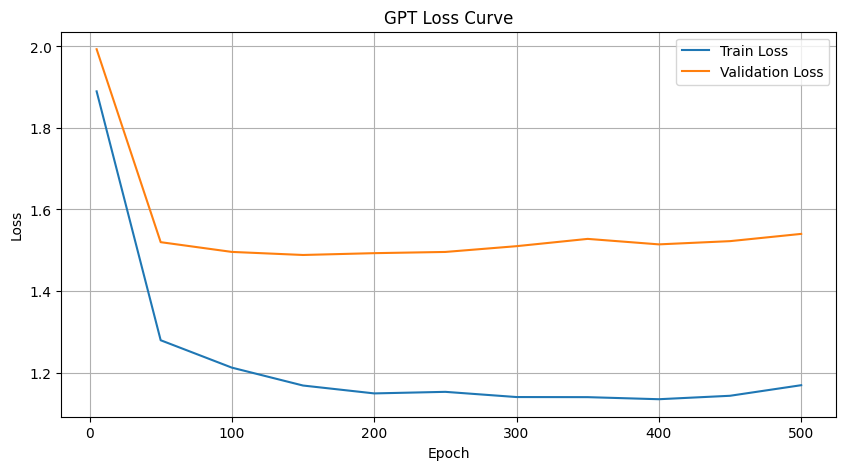

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(epochsRecordedGPT, trainLossesGPT, label='Train Loss')
plt.plot(epochsRecordedGPT, valLossesGPT, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('GPT Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

###Sample output at epoch 5
Is she dead?

I how gooy strand:
And that up hit sont kiuld
And brod woldstes funand in h: what 'they, he proter
Think kup a your the fless hink one of domble,
Go will whametes trooins

were cousiardfs thim of otheer at lut!


MAHENCUCE:
I of bitmath hus ongenr auge,
And all hore uf on I't saicty, to-thee hus haveld Huccckaan tthI gooks oof ven would.

Sucht Or ogong Sect-do So'd-my.


GTISTIO?


CAPERD:
But ifftartion,
And my will cond ether to vupald's wos with him.

KING Be KI Obeallous hight Mon!

Whicht

###Sample output at epoch 50
Is she dead?

CORIOLANUS:
I think him the time own of joy.

ROMEO:
This will prophastion to his proud wrong!
My bagforeth are never and left tongue of groan: he will
Hath I swell forgot the descrided agar, sweet will it
will be not of my sweet, by made to me
It is ports to.

CLAUDIO:
Come, as done and the that Duke of York; and that 'red,'
Once these hollow her shall into our pornouncil,
To shall plut by the people; for what show'd,
Our blood for it now, that refused perform'd
'Twere knuish informition out


###Sample output at epoch 500
Is she dead?

At speak left upon tstain my lord,
And gave yhou sudden that set us in gage.

AUFIDIUS:
O Signior Lord
To for yself?

VIRGILIA:
I will
Atknon.

AUFIDIUS:
He is the satisfie!

VOLUMNIA:
I hear ere to-night such bleeding him,
Asd he has at t
That found gentleman cannot may be climate
To stand you assemble has without
As once a case.

BRAKENBURY:
Tsend me have shed against tears, what mind,
As all to hear till I hear the weal
The looking coquence of death and vain.

KING RICHARD III:now sweet to L

##Part B — Train a PyTorch LSTM baseline (20 pts)


1. Implement a character-level LSTM in PyTorch (nn.Embedding → nn.LSTM → linear head).

https://docs.pytorch.org/docs/stable/generated/torch.nn.LSTM.html

https://www.geeksforgeeks.org/deep-learning/long-short-term-memory-networks-using-pytorch/

https://medium.com/@msouza.os/llm-from-scratch-with-pytorch-9f21808c6319

In [19]:
class CharLSTM(nn.Module):
    def __init__(self, vocabSize, embDim, hiddenDim, n_layers=2):
        super().__init__()
        self.embedding = nn.Embedding(vocabSize, embDim)
        self.lstm = nn.LSTM(embDim, hiddenDim, n_layers, batch_first=True)
        self.fc = nn.Linear(hiddenDim, vocabSize)

    def forward(self, x, targets=None):
        emb = self.embedding(x)
        self.lstm.flatten_parameters()
        out, _ = self.lstm(emb)
        logits = self.fc(out)

        loss = None
        if targets is not None:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            idxCondition = idx[:, -blockSize:]
            logits, _ = self(idxCondition)
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)
            idxNext = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idxNext), dim=1)
        return idx

2. Train on the same dataset and comparable context length (block_size).

3. At ~5, ~50, ~500 epochs: record train loss and validation loss; generate a 500–1000 character
sample using the same prompt/settings as Part A.


In [22]:
lstmModel = CharLSTM(vocabSize, 128, 256).to(device)
if 'cuda' in device:
    lstmModel = torch.compile(lstmModel)
optimizer = torch.optim.AdamW(lstmModel.parameters(), lr=1e-3)

In [23]:
trainLossessLTSM = []
valLossesLTSM = []
epochsRecordedLTSM = []

for epoch in range(1, maxEpochs+1):
    for step in range(stepsPerEpoch):
        xb, yb = makeBatch('train')
        with torch.autocast(device_type=device, dtype=torch.bfloat16):
            logits, loss = lstmModel(xb, yb)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(lstmModel.parameters(), max_norm=1.0)
        optimizer.step()

    if epoch in specialEpochs or epoch % 50 == 0:
        losses = estimateLoss(lstmModel)
        trainLossessLTSM.append(losses['train'].item())
        valLossesLTSM.append(losses['val'].item())
        epochsRecordedLTSM.append(epoch)
        print(f"Epoch {epoch}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    if epoch in specialEpochs:
        print(f"\n\nSample output at epoch {epoch}")
        print(f"{generate(lstmModel, prompt, 500)}\n\n")

Epoch 5: train loss 1.5270, val loss 1.6769


Sample output at epoch 5
Is she dead?

GLUMENE:
O, do but one?
Dear stood-pardom grance thee word of ham:
Have his busernend master him nated;
And thou art nothards the downy slefple in thoy faces.
How a word. Lord it not hast a.

KING RICHARD II:
My forjow the ragge in shall come it hand:
For them heart's love of make, form heare is the ligtas,
You, soul have be epcal enious benom of four,
God as and in prevized doth
That wh you are your skeeb that lettap that Than feep-say,
Sir this, and luted of prosase of Richmiti'd a drexentmy


Epoch 50: train loss 1.0552, val loss 1.5827


Sample output at epoch 50
Is she dead? and 'tis not on us.

Nurse:
Look, this is gone.

FLORIZEL:
Good mark, I can, you rather maid
Call victory can my fingingbroke that he is
In your hate, not marry.

First Offician:
Are you this value of your special prince?

GLOUCESTER:
So thou lovest on's on the night cozed me when
No joy affected her on Edward's state!
These o

4. Submit: (i) loss curve plot, (ii) three labeled samples.


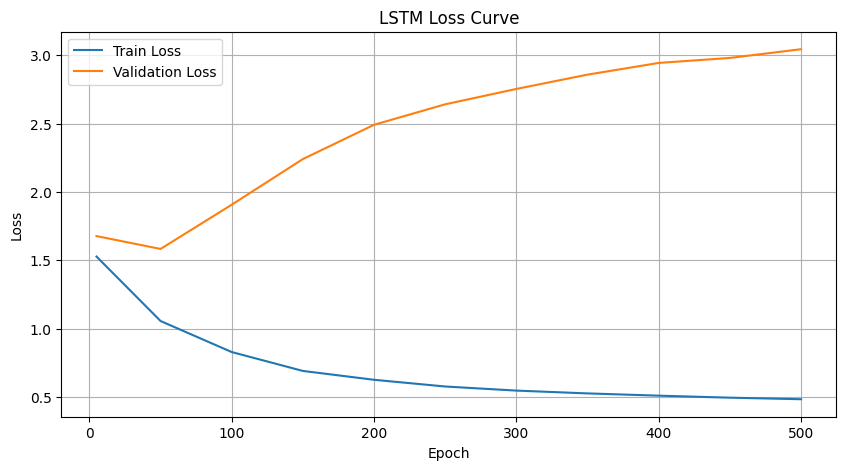

In [24]:
plt.figure(figsize=(10, 5))
plt.plot(epochsRecordedLTSM, trainLossessLTSM, label='Train Loss')
plt.plot(epochsRecordedLTSM, valLossesLTSM, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('LSTM Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

###Sample output at epoch 5
Is she dead?

GLUMENE:
O, do but one?
Dear stood-pardom grance thee word of ham:
Have his busernend master him nated;
And thou art nothards the downy slefple in thoy faces.
How a word. Lord it not hast a.

KING RICHARD II:
My forjow the ragge in shall come it hand:
For them heart's love of make, form heare is the ligtas,
You, soul have be epcal enious benom of four,
God as and in prevized doth
That wh you are your skeeb that lettap that Than feep-say,
Sir this, and luted of prosase of Richmiti'd a drexentmy


###Sample output at epoch 50
Is she dead? and 'tis not on us.

Nurse:
Look, this is gone.

FLORIZEL:
Good mark, I can, you rather maid
Call victory can my fingingbroke that he is
In your hate, not marry.

First Offician:
Are you this value of your special prince?

GLOUCESTER:
So thou lovest on's on the night cozed me when
No joy affected her on Edward's state!
These own concerns to piece which valiant though
Have fought be blind, 'tis painted.
The father bears the strength I blow it stails
Their imprisons' offence is dead thing thence:


###Sample output at epoch 500
Is she dead?

Ne'rl old:
Think it now will faith; I have put in worth
The falcon's ido bush,--much griefs the wool to crave
A servant to an unequent, foreing as those vayed
to insuble and purge but that, I parted. But noth,
If quarrel, thisus I am in an equre well
And something enteright then was in my prayers; for,
boar'd at home, that our striving flowers
Like end to your lasses as my commission,
You, and so betwixt unto this cause.

GREMIO:
What, not a rotten less!
That Rosaline, for victors murder'd homa

##Part C — Comparison writeup (10 pts)


• Briefly compare GPT vs LSTM at each checkpoint (5 → 50 → 500): coherence, formatting,
repetition loops, and character/word structure.

Epoch 5: Both of the models, very impressively, were able to figure out the formatting for dialouge. They used the all caps for names with colons and line breaks. Despite this progress, they are still struggling with generating actual english words at this point. The LSTM was able to use real names for this output, whereas the GPT was making them up.

Epoch 50: Both of the models, this time, were able to build real words. Additionally, they have also seemed to figure out sentence structure. The biggest weakness at this point is the occasional generation of garbled words. At a glance they look like real english (prophastion and knuish), but upon closer inspection, they aren't really. Additionally, GPT appears to have the upper hand in building sentences with better flow, where the LSTM is still generating somewhat disjointed sentences.

Epoch 500: Both are formatting full sentences with more appropriate uses of punctutation, but they are by no means perfect. Another big improvement is the use of what may consider classic Shakespearean, or more generally, Elizabeathen english vocabulary. The GPT model here is definetly better at generating a real dialouge with multiple characters interacting. Additionally, until the last person, they are all even from the same play. The same cannot be said for LSTM. It is still generating a much more rambly response where an actual meaning is still harder to decipher.

• Explain one significant differences between the models’ outputs and relate them to
architecture (attention vs recurrence) or training behavior (overfitting/underfitting,
optimization stability).

Attention versus reccurence is a good topic to discuss because the 500th epoch is a really good example of the differences.

GPT uses attention to maintain context. This means that the transformer architecture allows it to look back at all the characters in its context block when predicting its next character. This prevents severe memory loss throughout the generation of the sequence. This fact does well to explain the strucutural coherence the GPT model was able to keep.

LSTM on the other hand, uses recurrence. The model reads the entire context sequence sequentially. This means that the earlier characters in the sequence will have almost a negligible affect on the generation of the newest character, especially when compared to the GPT model. This architecture explains why the LSTM was prone to rambling and could not create anything with greater overall meaning.